In [1]:
%load_ext autoreload
%autoreload 3
%matplotlib inline
%config InlineBackend.figure_format = 'retina'

import os, sys
import importlib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sys.path.append('/Users/blancamartin/Desktop/Voytek_Lab/spike_waveform/spikeparam/AP_empirical_paper1/datasets/spe-1/spe1_helper_modules/')
import spk_feat_cluster_comp_analysis
importlib.reload(spk_feat_cluster_comp_analysis)
from spk_feat_cluster_comp_analysis import (
    compile_experiment_results,
    plot_spike_to_avg_distances,
    plot_spike_feature_within_vs_between,
)
import config
from config import SPE1_PICKLE_ROOT

In [2]:
cluster_pickle_dir = os.path.join(SPE1_PICKLE_ROOT, 'cluster_pickles')
spike_fit_dir      = os.path.join(SPE1_PICKLE_ROOT, 'spike_fit_pickles')

In [3]:
df_master = compile_experiment_results(cluster_pickle_dir)
df_master['sort_idx'] = df_master['cell_id'].str.extract('(\d+)').astype(int)
df_master = df_master.sort_values(['sort_idx', 'spike_feature']).drop(columns=['sort_idx'])

## Spike-to-average vs between-cell waveform distances

Within = each individual spike vs its own cell's mean waveform (~167k spikes). Between = each spike vs every other cell's mean (~7M comparisons). Both are spike-to-average nRMSE/cos_sim.

Loaded 43 cells, 167,006 total spikes
Between: 7,014,252 spike-to-avg comparisons across 43 cells


/Users/blancamartin/Desktop/Voytek_Lab/spike_waveform/spikeparam/AP_empirical_paper1/datasets/spe-1/spe1_helper_modules/spk_feat_cluster_comp_analysis.py:2432: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=plot_df, x="group", y="value", order=GROUP_ORDER,
/Users/blancamartin/Desktop/Voytek_Lab/spike_waveform/spikeparam/AP_empirical_paper1/datasets/spe-1/spe1_helper_modules/spk_feat_cluster_comp_analysis.py:2435: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.stripplot(data=plot_df, x="group", y="value", order=GROUP_ORDER,


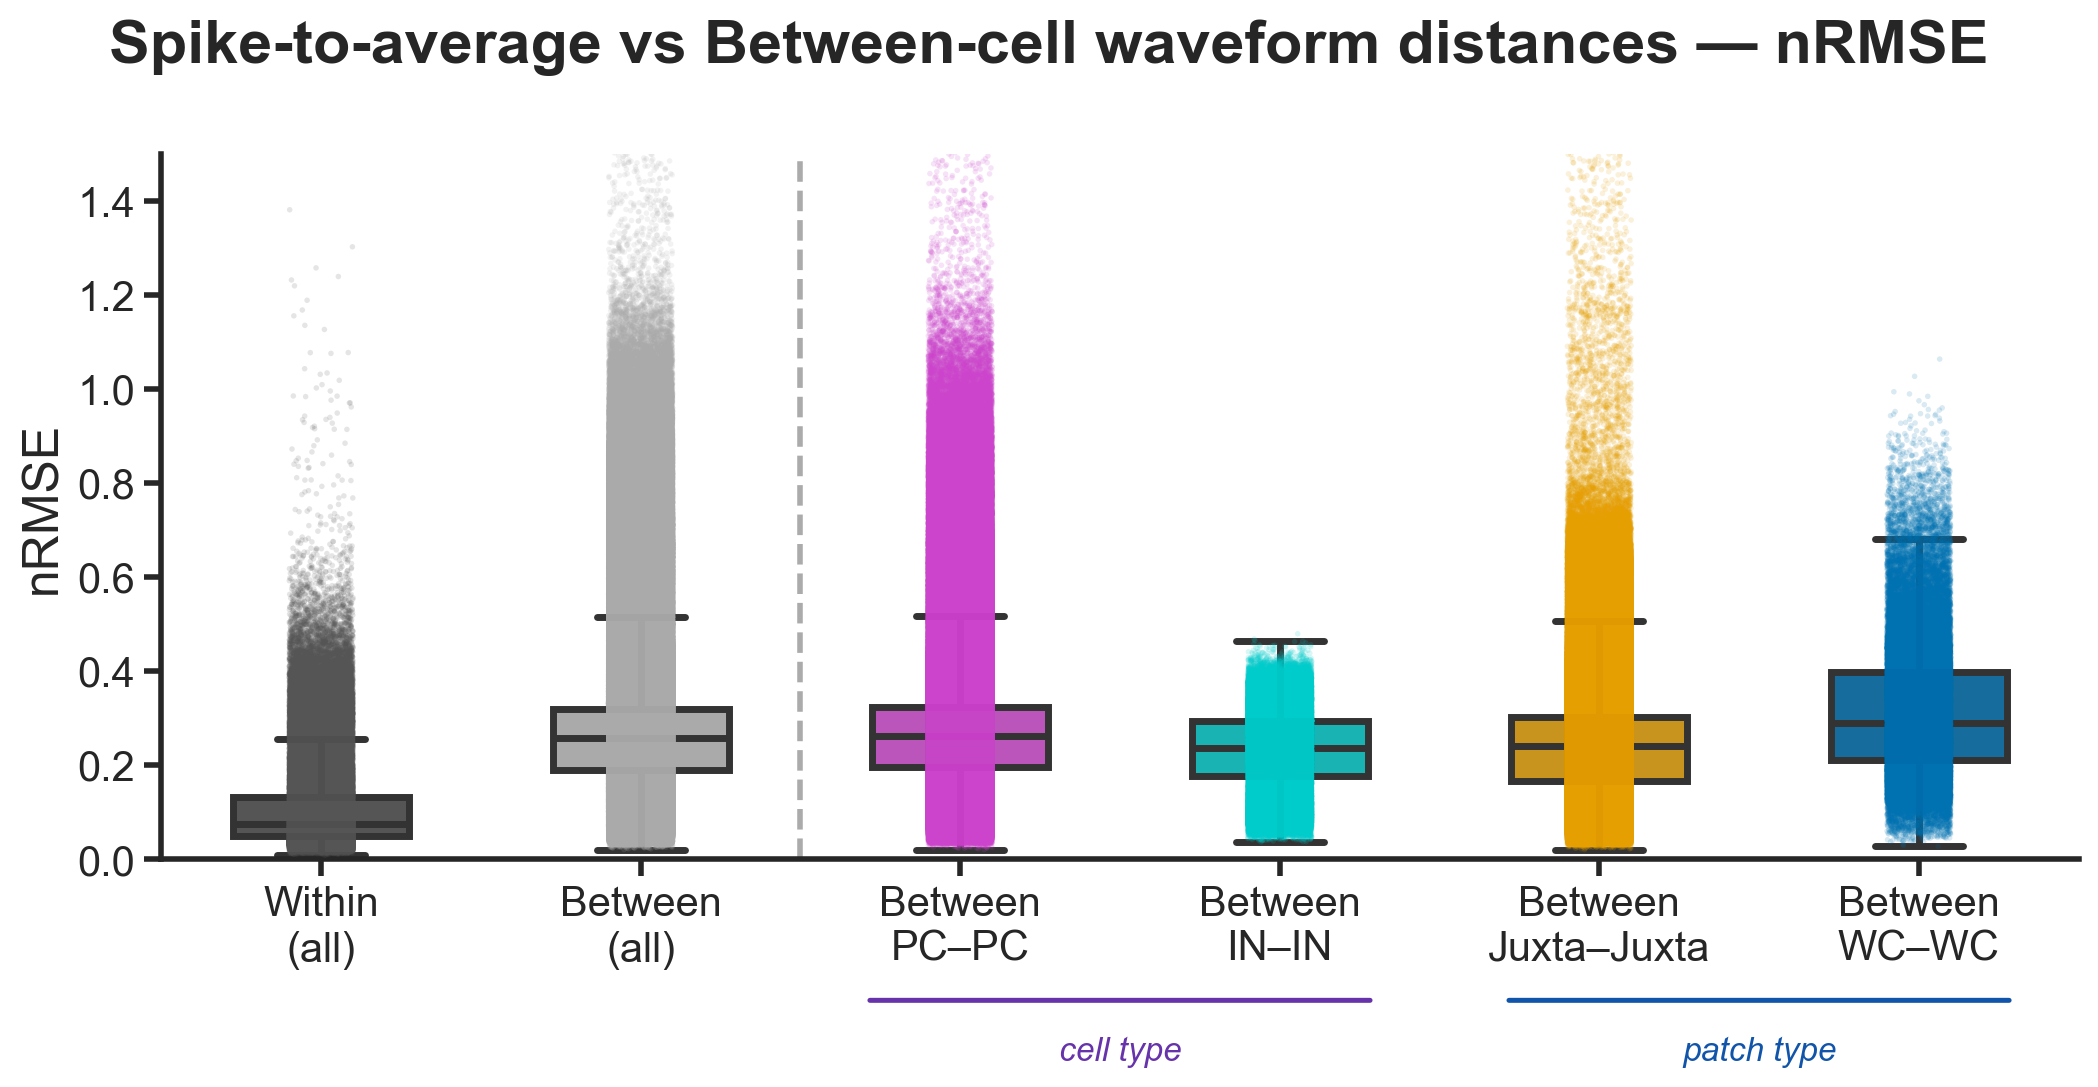


── nRMSE (spike-to-avg) ──
  Within (all)          : median=0.076  IQR=[0.050, 0.133]  n=167006
  Between (all)         : median=0.257  IQR=[0.190, 0.320]  n=7014252
  Between PC–PC         : median=0.263  IQR=[0.196, 0.324]  n=4534992
  Between IN–IN         : median=0.236  IQR=[0.178, 0.294]  n=205170
  Between Juxta–Juxta   : median=0.241  IQR=[0.167, 0.303]  n=5460016
  Between WC–WC         : median=0.290  IQR=[0.211, 0.399]  n=77752


/Users/blancamartin/Desktop/Voytek_Lab/spike_waveform/spikeparam/AP_empirical_paper1/datasets/spe-1/spe1_helper_modules/spk_feat_cluster_comp_analysis.py:2432: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=plot_df, x="group", y="value", order=GROUP_ORDER,
/Users/blancamartin/Desktop/Voytek_Lab/spike_waveform/spikeparam/AP_empirical_paper1/datasets/spe-1/spe1_helper_modules/spk_feat_cluster_comp_analysis.py:2435: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.stripplot(data=plot_df, x="group", y="value", order=GROUP_ORDER,


In [ ]:
plot_spike_to_avg_distances(
    df_master,
    wf_dir=cluster_pickle_dir,
    spike_fit_dir=spike_fit_dir,
    half_win=75,
)

## Within vs between: individual spike features

For each waveform feature: within = |spike_value − own_cell_mean|; between = |mean_i − mean_j| for all cell pairs. Shows whether each feature varies more within a cell (spike-to-spike) or between cells.

[spike_feature_wb] mode=simple  cache=MISS — computing (will cache after)
  peak_amp: loaded from cache


/Users/blancamartin/Desktop/Voytek_Lab/spike_waveform/spikeparam/AP_empirical_paper1/datasets/spe-1/spe1_helper_modules/spk_feat_cluster_comp_analysis.py:2603: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=full_df, x="group", y="value", order=GROUP_ORDER,
/Users/blancamartin/Desktop/Voytek_Lab/spike_waveform/spikeparam/AP_empirical_paper1/datasets/spe-1/spe1_helper_modules/spk_feat_cluster_comp_analysis.py:2606: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.stripplot(data=strip_df, x="group", y="value", order=GROUP_ORDER,


  peak_amp             Within                : median=10.7  IQR=[2.158, 29.38]  n=166,349
  peak_amp             Between               : median=139.7  IQR=[57.27, 233.3]  n=6,487,611
  peak_sharpness: loaded from cache


/Users/blancamartin/Desktop/Voytek_Lab/spike_waveform/spikeparam/AP_empirical_paper1/datasets/spe-1/spe1_helper_modules/spk_feat_cluster_comp_analysis.py:2603: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=full_df, x="group", y="value", order=GROUP_ORDER,
/Users/blancamartin/Desktop/Voytek_Lab/spike_waveform/spikeparam/AP_empirical_paper1/datasets/spe-1/spe1_helper_modules/spk_feat_cluster_comp_analysis.py:2606: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.stripplot(data=strip_df, x="group", y="value", order=GROUP_ORDER,


  peak_sharpness       Within                : median=5.513  IQR=[0.3296, 18.1]  n=166,349
  peak_sharpness       Between               : median=54.76  IQR=[20.16, 100.1]  n=6,487,611
  peak_width: computed and cached → _feat_wb_simple_peak_width.npz


...

  exp_lambda           Within                : median=1.027  IQR=[0.1724, 2.434]  n=166,349
  exp_lambda           Between               : median=3.035  IQR=[1.048, 6.463]  n=6,487,611
  inflection_amp: computed and cached → _feat_wb_simple_inflection_amp.npz


/Users/blancamartin/Desktop/Voytek_Lab/spike_waveform/spikeparam/AP_empirical_paper1/datasets/spe-1/spe1_helper_modules/spk_feat_cluster_comp_analysis.py:2603: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=full_df, x="group", y="value", order=GROUP_ORDER,
/Users/blancamartin/Desktop/Voytek_Lab/spike_waveform/spikeparam/AP_empirical_paper1/datasets/spe-1/spe1_helper_modules/spk_feat_cluster_comp_analysis.py:2606: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.stripplot(data=strip_df, x="group", y="value", order=GROUP_ORDER,


  inflection_amp       Within                : median=3.732  IQR=[0.653, 8.178]  n=166,349
  inflection_amp       Between               : median=6.013  IQR=[2.755, 11.06]  n=6,487,611
  inflection_time: computed and cached → _feat_wb_simple_inflection_time.npz


/Users/blancamartin/Desktop/Voytek_Lab/spike_waveform/spikeparam/AP_empirical_paper1/datasets/spe-1/spe1_helper_modules/spk_feat_cluster_comp_analysis.py:2603: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=full_df, x="group", y="value", order=GROUP_ORDER,
/Users/blancamartin/Desktop/Voytek_Lab/spike_waveform/spikeparam/AP_empirical_paper1/datasets/spe-1/spe1_helper_modules/spk_feat_cluster_comp_analysis.py:2606: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.stripplot(data=strip_df, x="group", y="value", order=GROUP_ORDER,


  inflection_time      Within                : median=0.03405  IQR=[0.01404, 0.08525]  n=166,349
  inflection_time      Between               : median=0.162  IQR=[0.05732, 0.471]  n=6,487,611


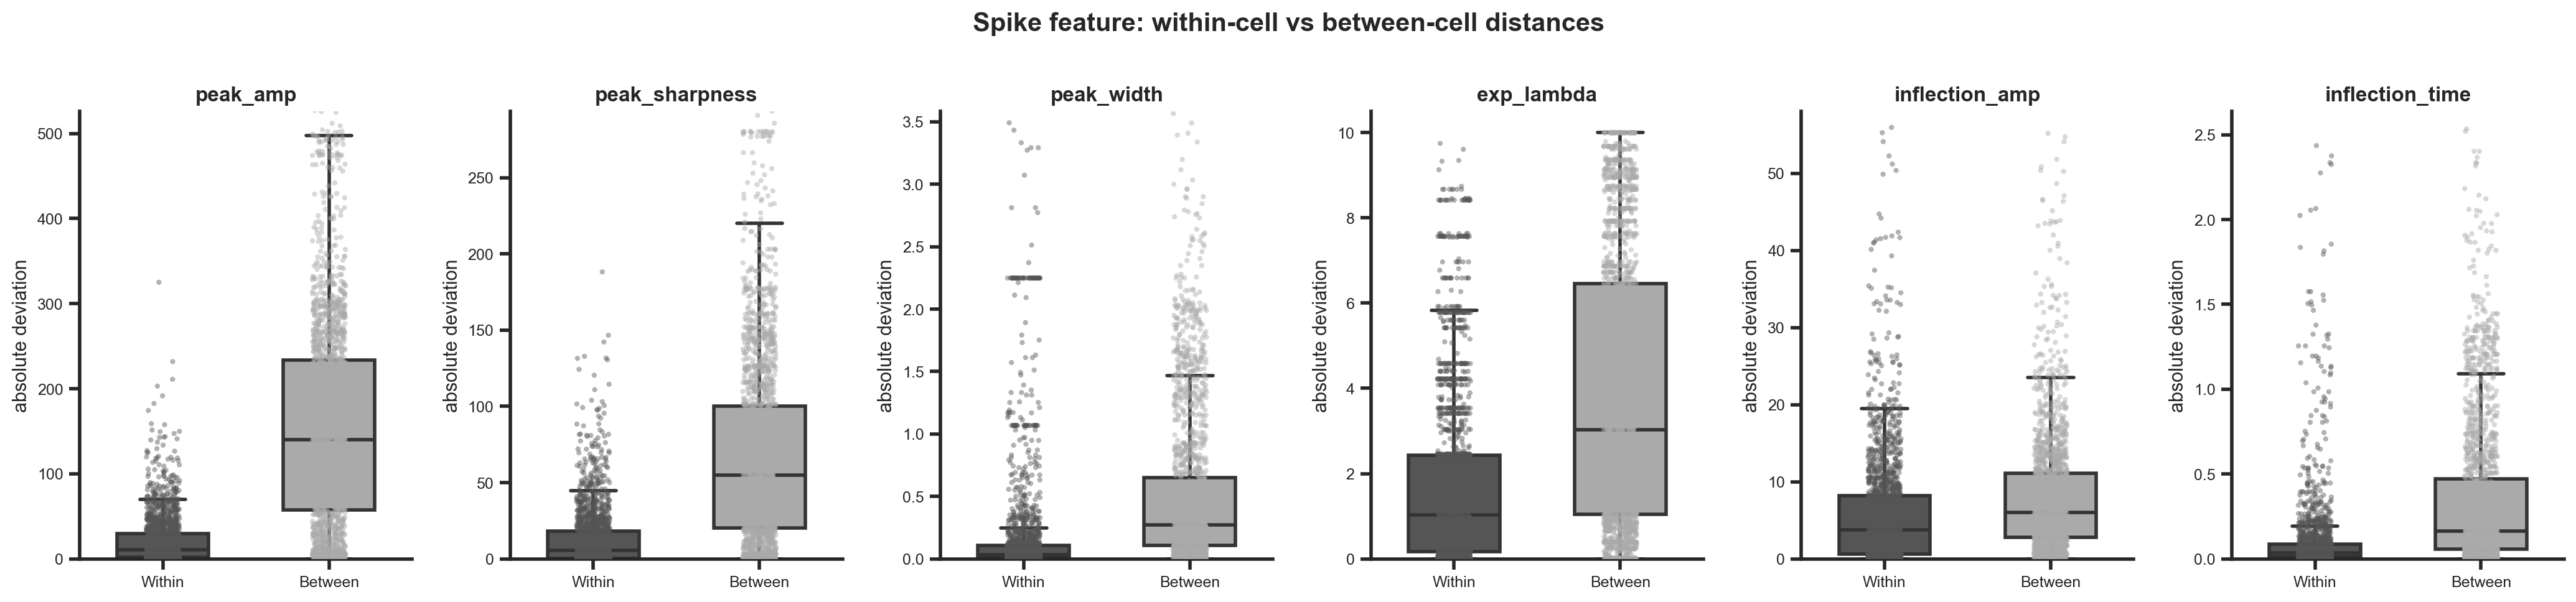

In [ ]:
plot_spike_feature_within_vs_between(cluster_pickle_dir)

[spike_feature_wb] mode=detailed  cache=MISS — computing (will cache after)
  peak_amp: computed and cached → _feat_wb_detailed_peak_amp.npz


/Users/blancamartin/Desktop/Voytek_Lab/spike_waveform/spikeparam/AP_empirical_paper1/datasets/spe-1/spe1_helper_modules/spk_feat_cluster_comp_analysis.py:2603: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=full_df, x="group", y="value", order=GROUP_ORDER,
/Users/blancamartin/Desktop/Voytek_Lab/spike_waveform/spikeparam/AP_empirical_paper1/datasets/spe-1/spe1_helper_modules/spk_feat_cluster_comp_analysis.py:2606: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.stripplot(data=strip_df, x="group", y="value", order=GROUP_ORDER,


  peak_amp             Within (all)          : median=10.7  IQR=[2.158, 29.38]  n=166,349
  peak_amp             Between (all)         : median=139.7  IQR=[57.27, 233.3]  n=6,487,611
  peak_amp             Between PC–PC         : median=136.5  IQR=[59.91, 229.8]  n=4,260,982
  peak_amp             Between IN–IN         : median=216  IQR=[58.9, 268]  n=164,104
  peak_amp             Between Juxta–Juxta   : median=137.2  IQR=[61.97, 229.5]  n=4,994,974
  peak_amp             Between WC–WC         : median=6.33  IQR=[3.657, 9.735]  n=77,752


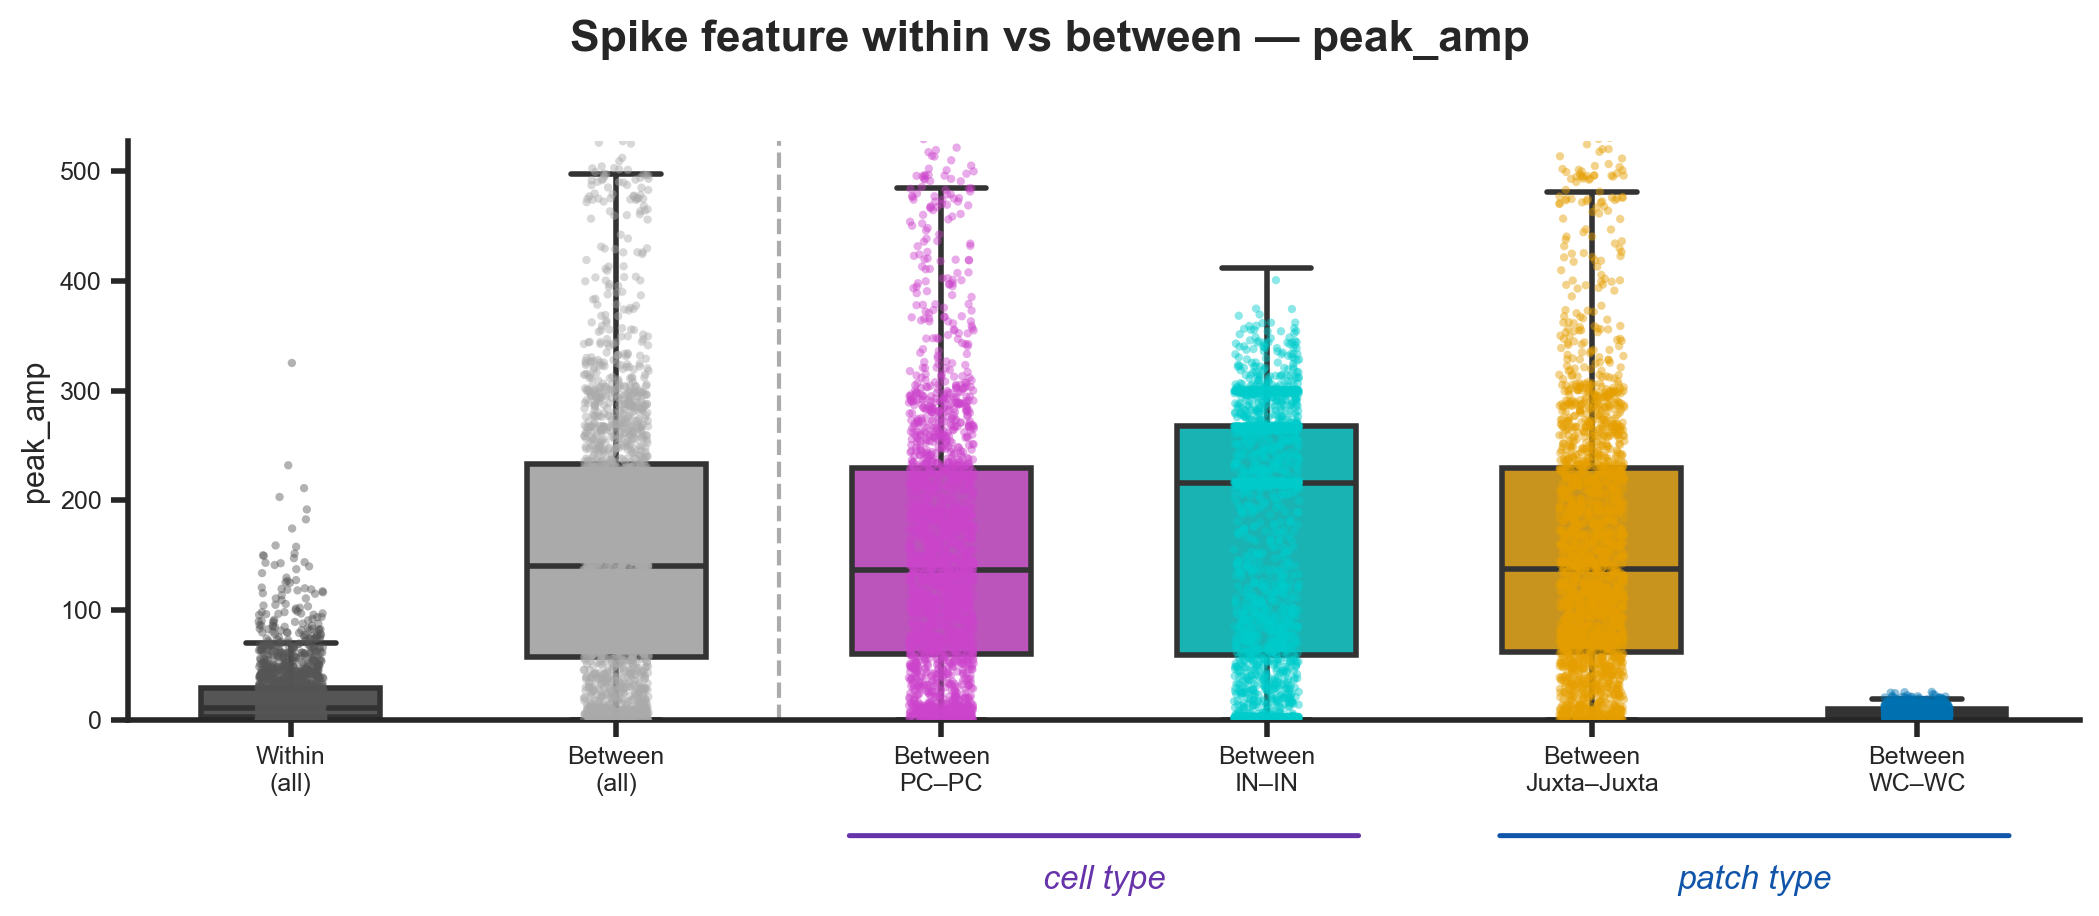

  peak_sharpness: computed and cached → _feat_wb_detailed_peak_sharpness.npz


/Users/blancamartin/Desktop/Voytek_Lab/spike_waveform/spikeparam/AP_empirical_paper1/datasets/spe-1/spe1_helper_modules/spk_feat_cluster_comp_analysis.py:2603: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=full_df, x="group", y="value", order=GROUP_ORDER,
/Users/blancamartin/Desktop/Voytek_Lab/spike_waveform/spikeparam/AP_empirical_paper1/datasets/spe-1/spe1_helper_modules/spk_feat_cluster_comp_analysis.py:2606: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.stripplot(data=strip_df, x="group", y="value", order=GROUP_ORDER,


  peak_sharpness       Within (all)          : median=5.513  IQR=[0.3296, 18.1]  n=166,349
  peak_sharpness       Between (all)         : median=54.76  IQR=[20.16, 100.1]  n=6,487,611
  peak_sharpness       Between PC–PC         : median=48.49  IQR=[19.61, 90.88]  n=4,260,982
  peak_sharpness       Between IN–IN         : median=84.07  IQR=[49.25, 123.8]  n=164,104
  peak_sharpness       Between Juxta–Juxta   : median=56.94  IQR=[25.15, 101]  n=4,994,974
  peak_sharpness       Between WC–WC         : median=0.1664  IQR=[0.09307, 0.2505]  n=77,752


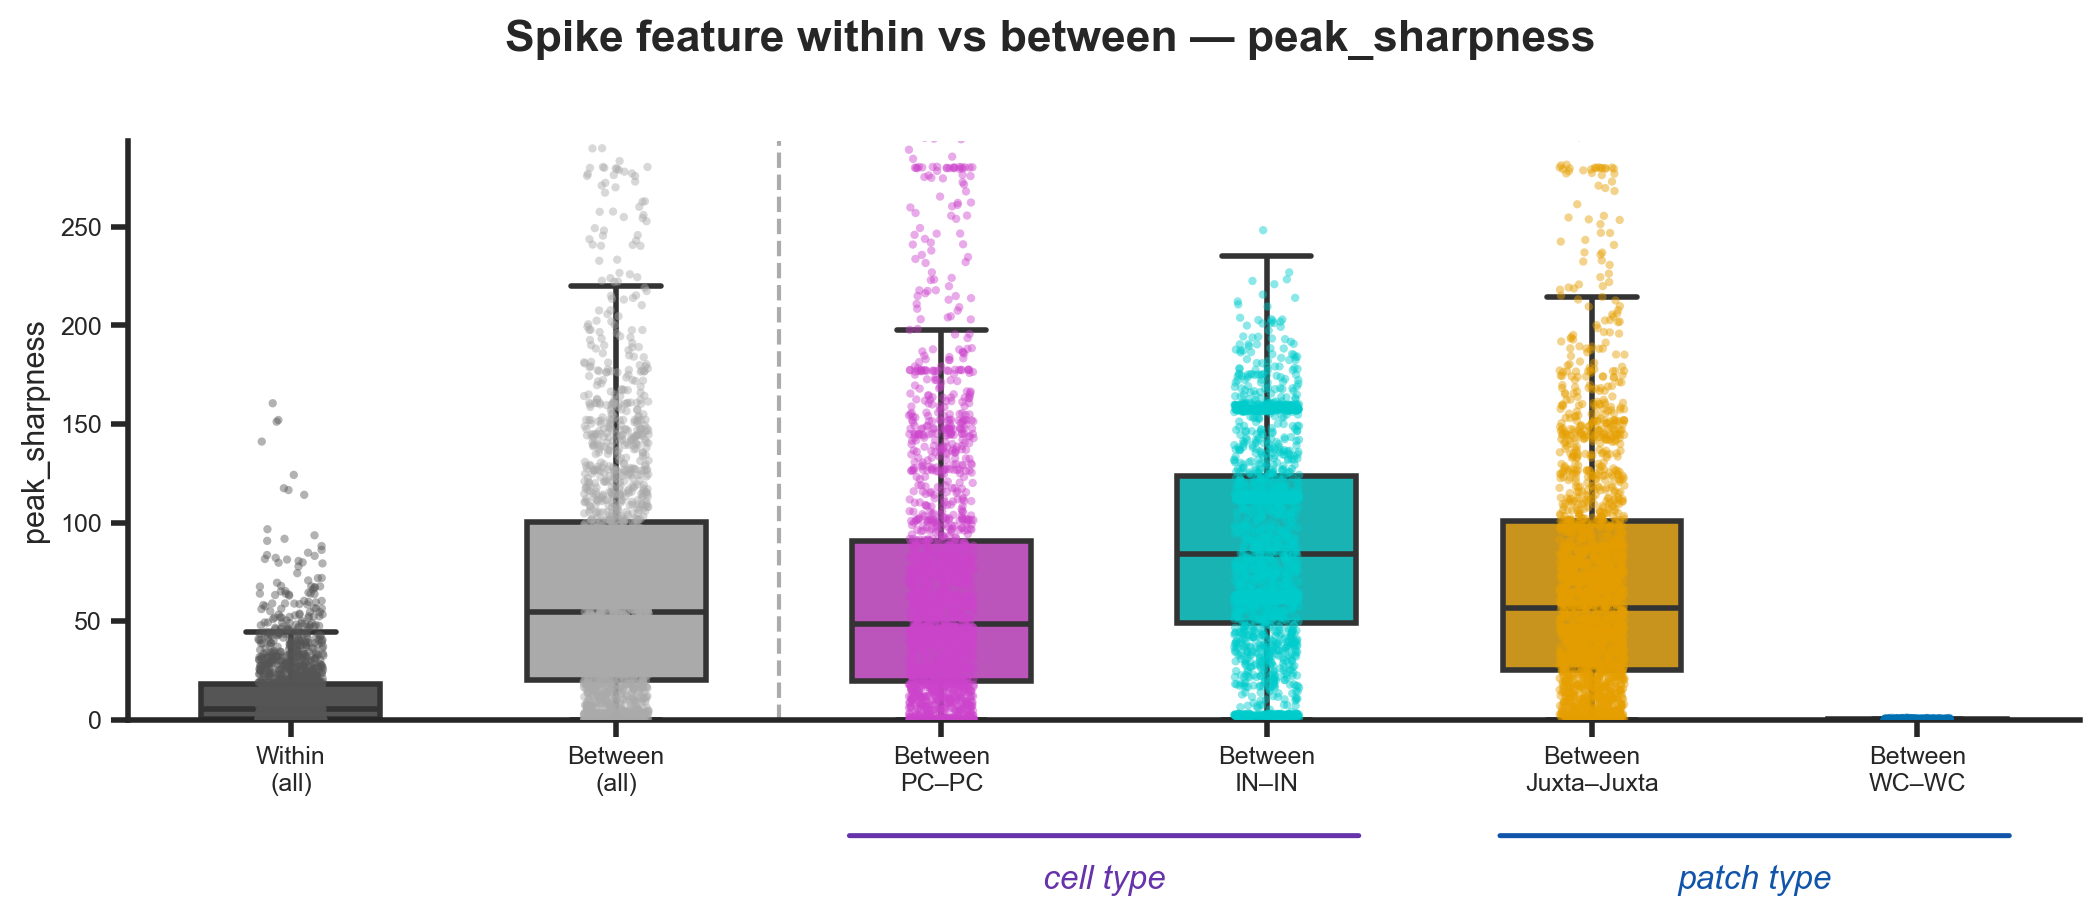

  peak_width: computed and cached → _feat_wb_detailed_peak_width.npz


/Users/blancamartin/Desktop/Voytek_Lab/spike_waveform/spikeparam/AP_empirical_paper1/datasets/spe-1/spe1_helper_modules/spk_feat_cluster_comp_analysis.py:2603: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=full_df, x="group", y="value", order=GROUP_ORDER,
/Users/blancamartin/Desktop/Voytek_Lab/spike_waveform/spikeparam/AP_empirical_paper1/datasets/spe-1/spe1_helper_modules/spk_feat_cluster_comp_analysis.py:2606: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.stripplot(data=strip_df, x="group", y="value", order=GROUP_ORDER,


  peak_width           Within (all)          : median=0.03417  IQR=[0.01274, 0.1058]  n=166,349
  peak_width           Between (all)         : median=0.2727  IQR=[0.1073, 0.6504]  n=6,487,611
  peak_width           Between PC–PC         : median=0.3231  IQR=[0.1342, 0.8441]  n=4,260,982
  peak_width           Between IN–IN         : median=0.1135  IQR=[0.04935, 0.3093]  n=164,104
  peak_width           Between Juxta–Juxta   : median=0.1885  IQR=[0.07994, 0.3676]  n=4,994,974
  peak_width           Between WC–WC         : median=1.069  IQR=[0.5307, 1.851]  n=77,752


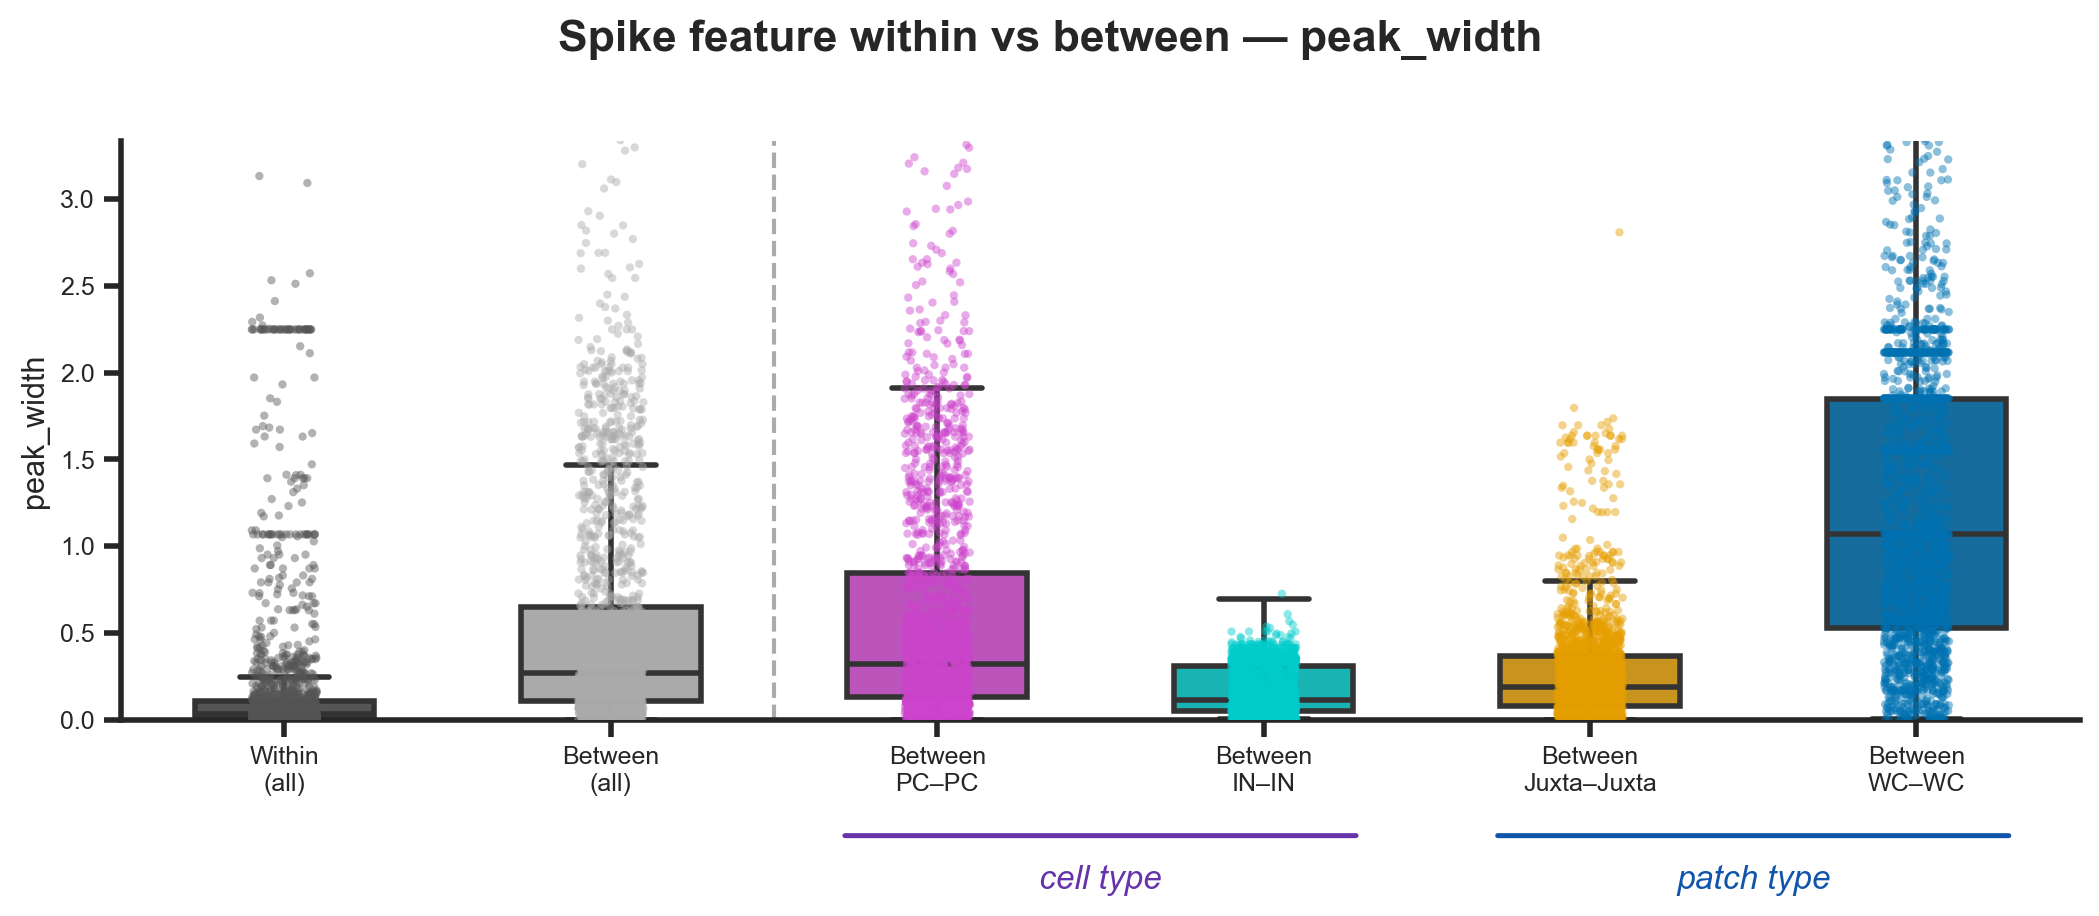

  exp_lambda: computed and cached → _feat_wb_detailed_exp_lambda.npz


/Users/blancamartin/Desktop/Voytek_Lab/spike_waveform/spikeparam/AP_empirical_paper1/datasets/spe-1/spe1_helper_modules/spk_feat_cluster_comp_analysis.py:2603: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=full_df, x="group", y="value", order=GROUP_ORDER,
/Users/blancamartin/Desktop/Voytek_Lab/spike_waveform/spikeparam/AP_empirical_paper1/datasets/spe-1/spe1_helper_modules/spk_feat_cluster_comp_analysis.py:2606: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.stripplot(data=strip_df, x="group", y="value", order=GROUP_ORDER,


  exp_lambda           Within (all)          : median=1.027  IQR=[0.1724, 2.434]  n=166,349
  exp_lambda           Between (all)         : median=3.035  IQR=[1.048, 6.463]  n=6,487,611
  exp_lambda           Between PC–PC         : median=2.943  IQR=[1.047, 6.303]  n=4,260,982
  exp_lambda           Between IN–IN         : median=4.22  IQR=[1.586, 8.22]  n=164,104
  exp_lambda           Between Juxta–Juxta   : median=3.412  IQR=[1.355, 6.693]  n=4,994,974
  exp_lambda           Between WC–WC         : median=0.5282  IQR=[0.308, 0.7545]  n=77,752


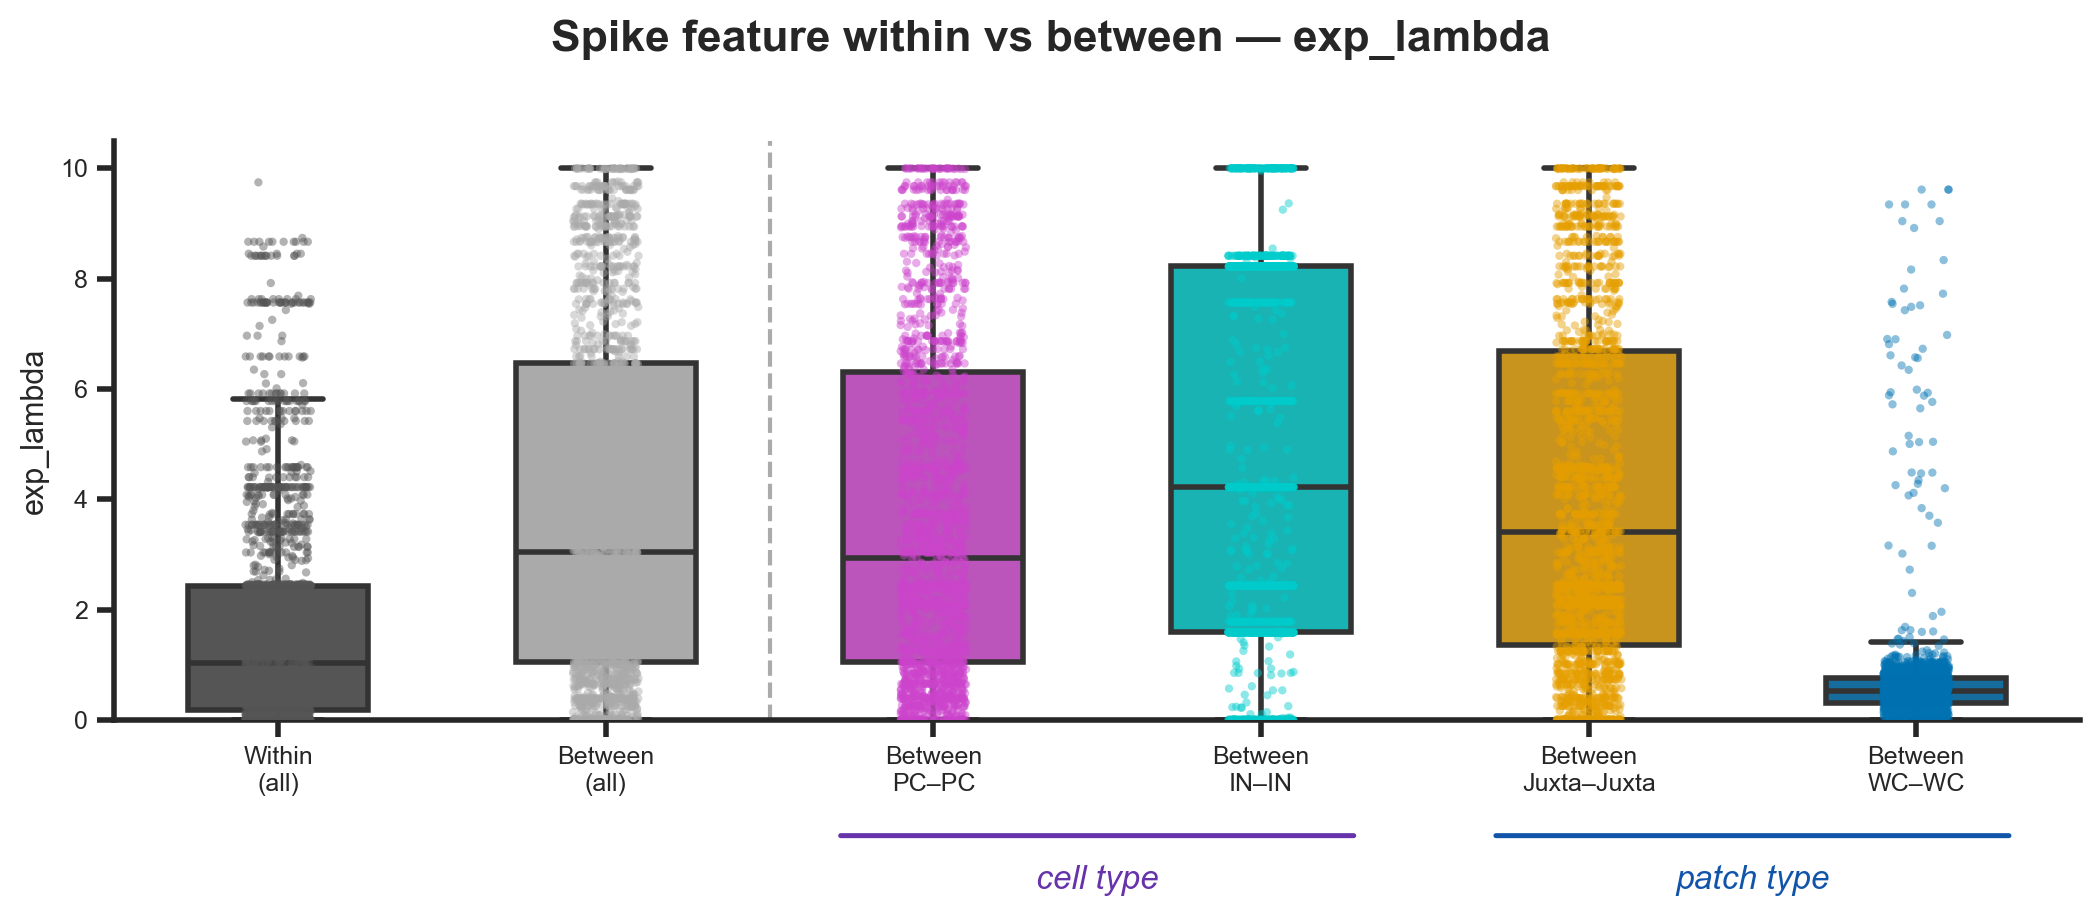

  inflection_amp: computed and cached → _feat_wb_detailed_inflection_amp.npz


/Users/blancamartin/Desktop/Voytek_Lab/spike_waveform/spikeparam/AP_empirical_paper1/datasets/spe-1/spe1_helper_modules/spk_feat_cluster_comp_analysis.py:2603: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=full_df, x="group", y="value", order=GROUP_ORDER,
/Users/blancamartin/Desktop/Voytek_Lab/spike_waveform/spikeparam/AP_empirical_paper1/datasets/spe-1/spe1_helper_modules/spk_feat_cluster_comp_analysis.py:2606: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.stripplot(data=strip_df, x="group", y="value", order=GROUP_ORDER,


  inflection_amp       Within (all)          : median=3.732  IQR=[0.653, 8.178]  n=166,349
  inflection_amp       Between (all)         : median=6.013  IQR=[2.755, 11.06]  n=6,487,611
  inflection_amp       Between PC–PC         : median=6.008  IQR=[2.784, 11.55]  n=4,260,982
  inflection_amp       Between IN–IN         : median=7.767  IQR=[3.469, 10.86]  n=164,104
  inflection_amp       Between Juxta–Juxta   : median=6.185  IQR=[2.895, 11.46]  n=4,994,974
  inflection_amp       Between WC–WC         : median=3.795  IQR=[1.923, 9.708]  n=77,752


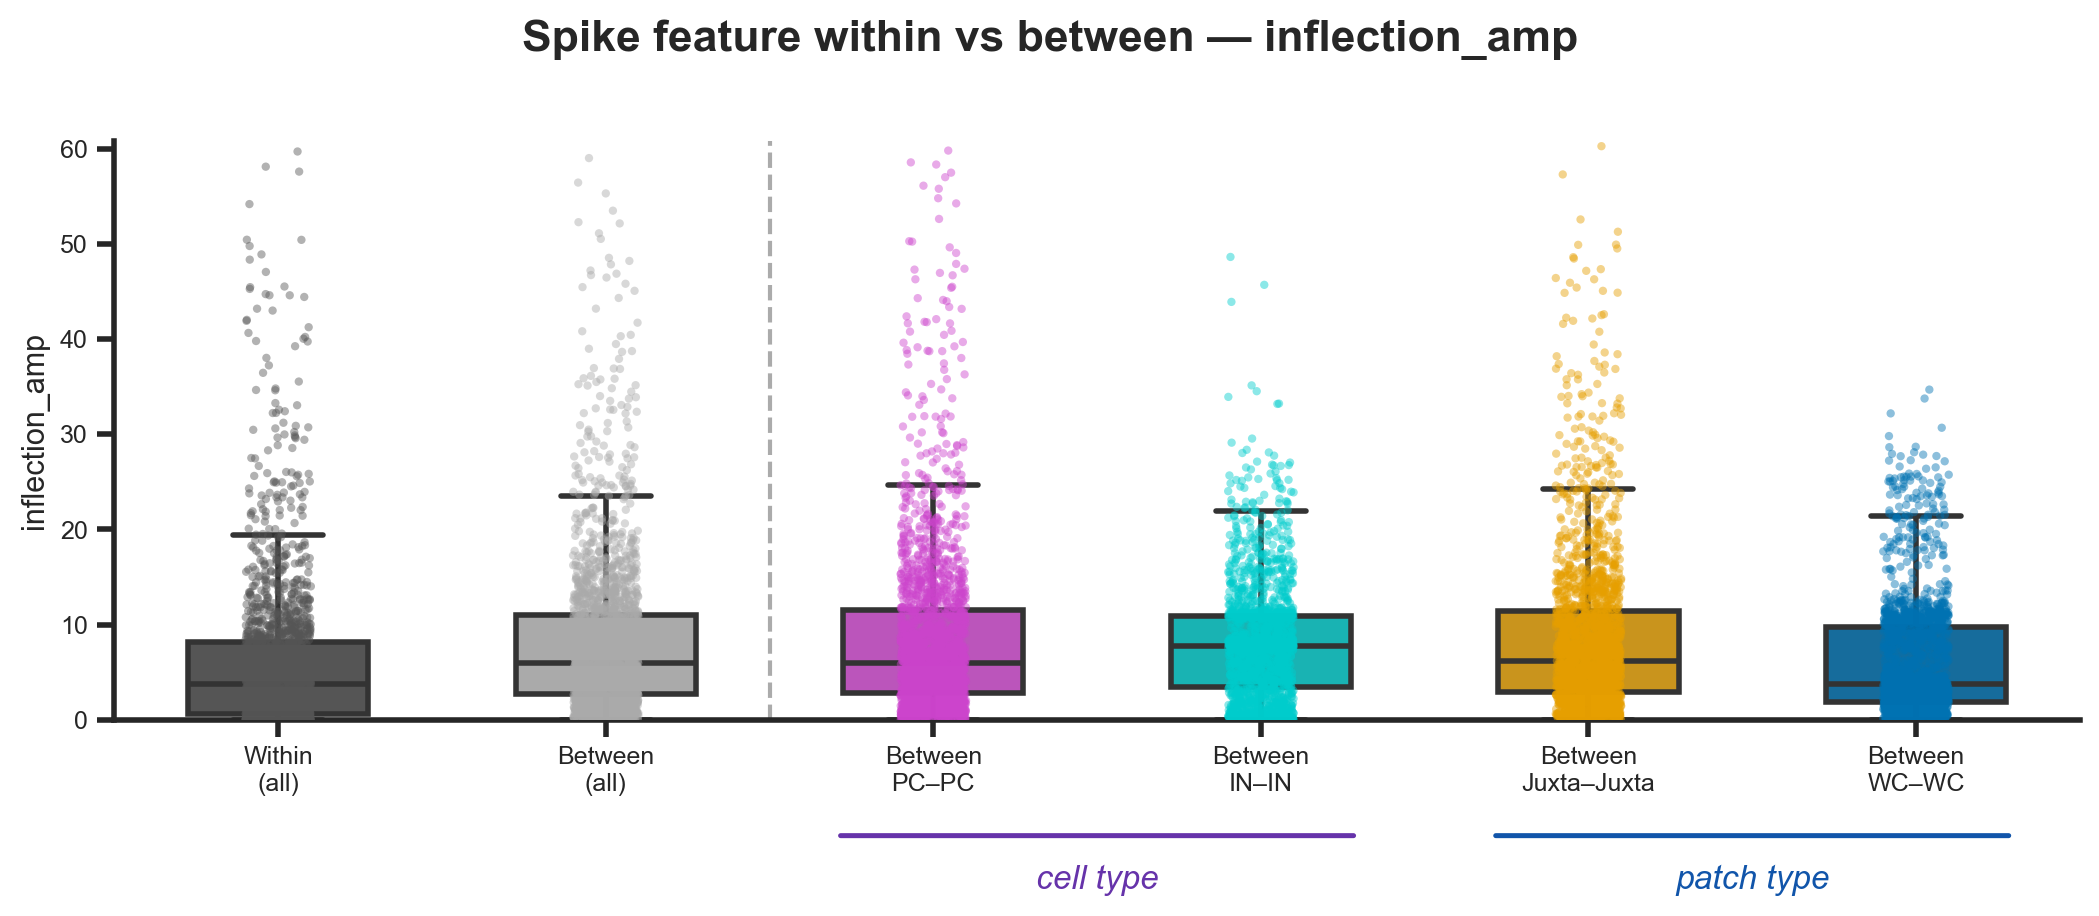

  inflection_time: computed and cached → _feat_wb_detailed_inflection_time.npz


/Users/blancamartin/Desktop/Voytek_Lab/spike_waveform/spikeparam/AP_empirical_paper1/datasets/spe-1/spe1_helper_modules/spk_feat_cluster_comp_analysis.py:2603: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=full_df, x="group", y="value", order=GROUP_ORDER,
/Users/blancamartin/Desktop/Voytek_Lab/spike_waveform/spikeparam/AP_empirical_paper1/datasets/spe-1/spe1_helper_modules/spk_feat_cluster_comp_analysis.py:2606: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.stripplot(data=strip_df, x="group", y="value", order=GROUP_ORDER,


  inflection_time      Within (all)          : median=0.03405  IQR=[0.01404, 0.08525]  n=166,349
  inflection_time      Between (all)         : median=0.162  IQR=[0.05732, 0.471]  n=6,487,611
  inflection_time      Between PC–PC         : median=0.1985  IQR=[0.07367, 0.5708]  n=4,260,982
  inflection_time      Between IN–IN         : median=0.06643  IQR=[0.02899, 0.2058]  n=164,104
  inflection_time      Between Juxta–Juxta   : median=0.1037  IQR=[0.04514, 0.222]  n=4,994,974
  inflection_time      Between WC–WC         : median=0.5849  IQR=[0.2648, 0.9541]  n=77,752


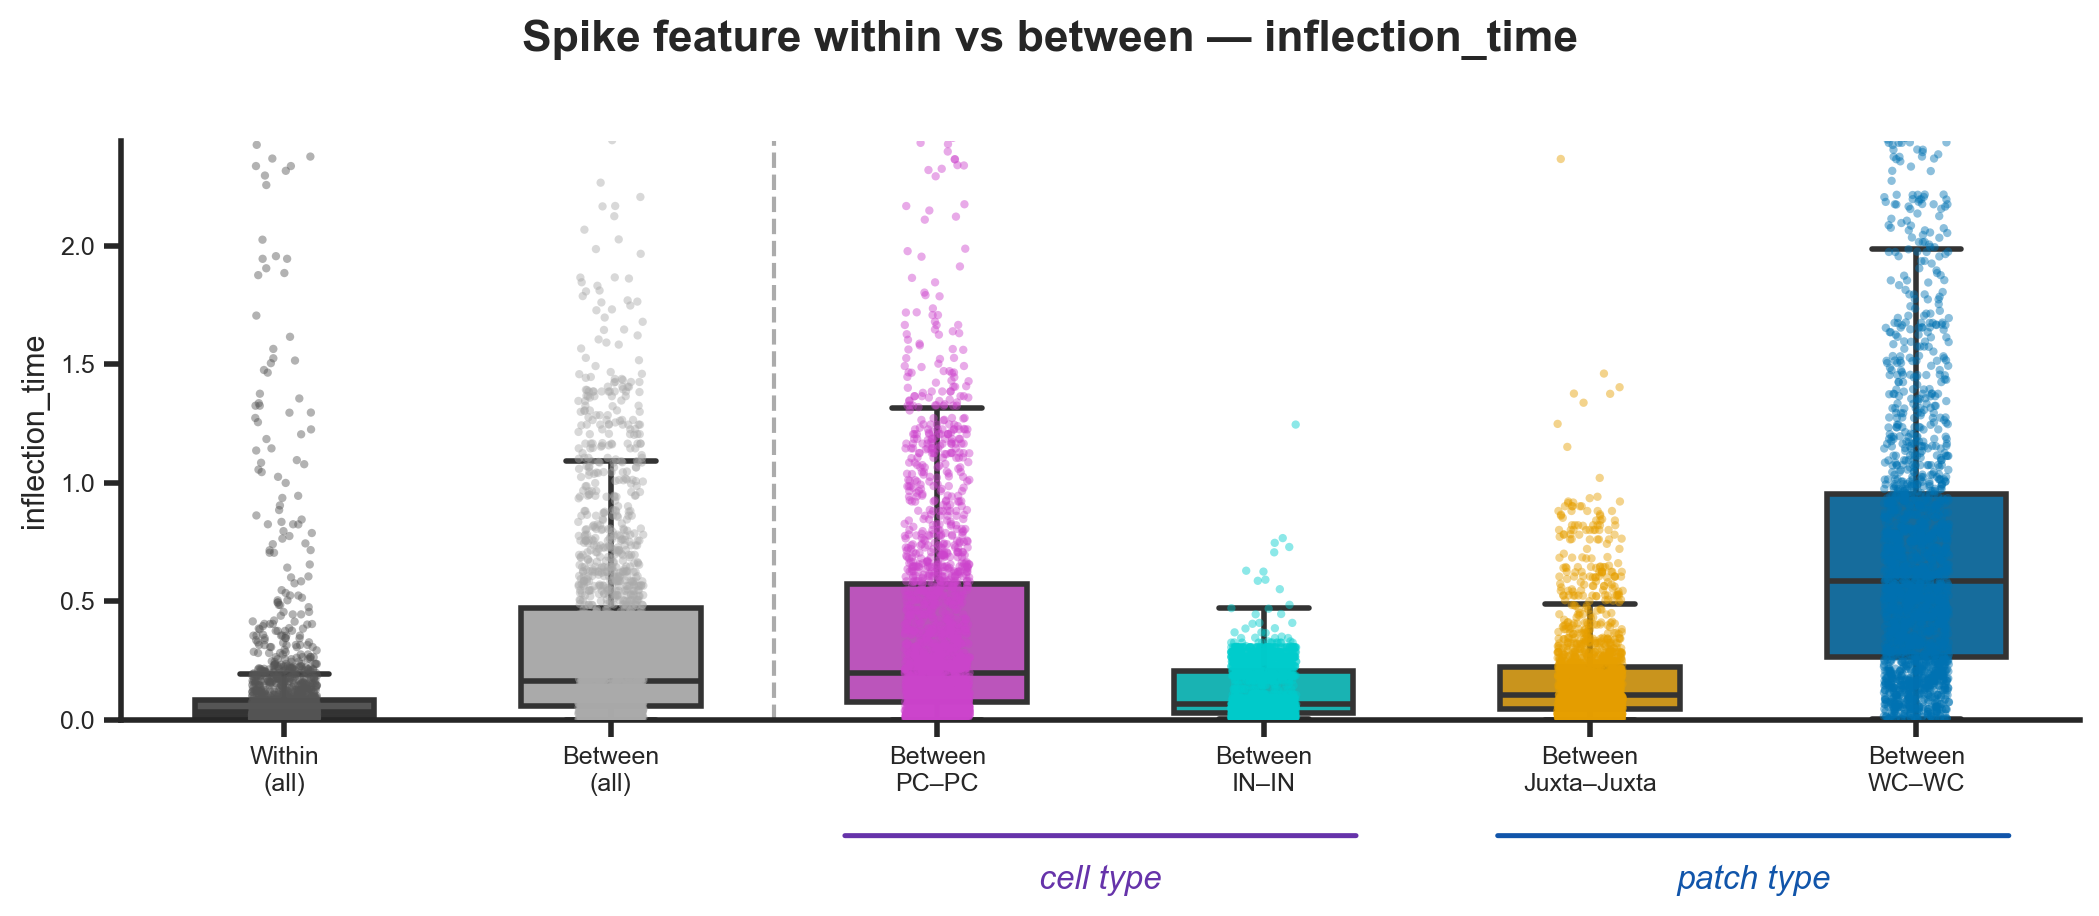

In [ ]:
plot_spike_feature_within_vs_between(cluster_pickle_dir, detailed=True, df_master=df_master)

Each spike is compared to the mean waveform of its own cell (within) and to the mean waveform of every other cell (between). Both distances are spike-to-average nRMSE/cos_sim, making the comparison scale-consistent. Within is ~167k spikes; between is ~7M comparisons across 38 cells.